In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bodyPerformance.csv to bodyPerformance.csv


In [3]:
data = pd.read_csv('bodyPerformance.csv')
df = data.copy()
df.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
print(f'with duplicates:{df.shape}')
df.drop_duplicates(inplace=True)
print(f'without duplicates:{df.shape}')

with duplicates:(13393, 12)
without duplicates:(13392, 12)


In [7]:
df_copy = df.copy()

# Columns distribution

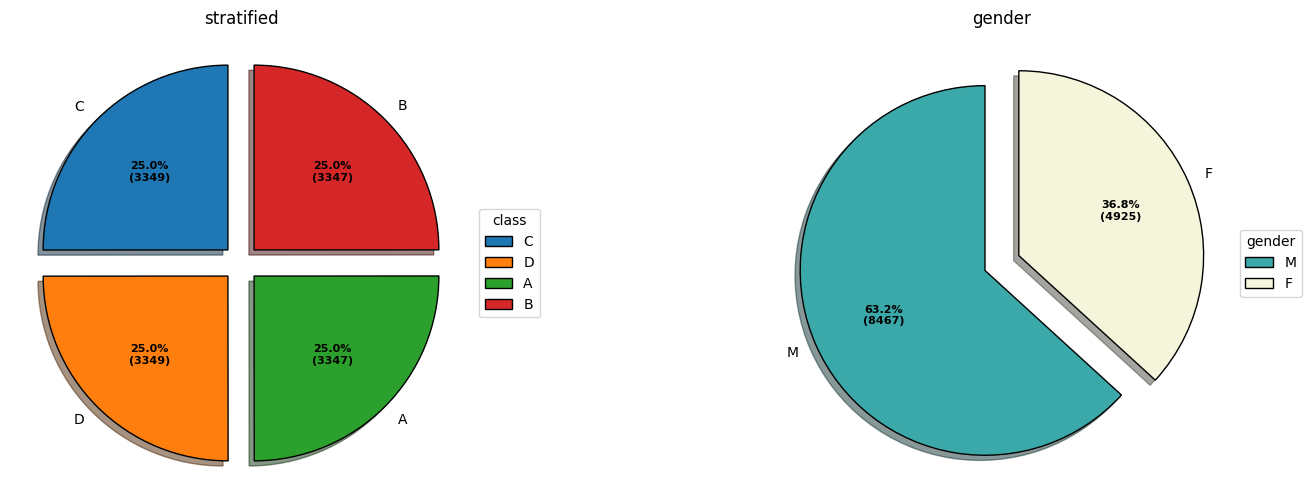

In [8]:
# Creating autocpt arguments
def pie(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%\n({:d})".format(pct, absolute) if pct > 8 else ''

fig, axs = plt.subplots(1,2,figsize =(18, 6))

# class
wedges1, texts1, autotexts1 = axs[0].pie(df['class'].value_counts(),
                                      autopct = lambda pct: pie(pct, df['class'].value_counts()),
                                      explode = (.1, .1, .1, 0.1),
                                      labels = df['class'].value_counts().index, shadow = True,
                                      startangle = 90, wedgeprops = { 'linewidth' : 1, 'edgecolor' : "black" },
                                      textprops = dict(color ="black"),)

# Adding legend
axs[0].legend(wedges1, df['class'].value_counts().index, title='class',
          loc ="center left", bbox_to_anchor =(1, 0, 0.5, 1))

plt.setp(autotexts1, size = 8, weight ="bold")
axs[0].set_title("stratified")

# gender
wedges1, texts1, autotexts1 = axs[1].pie(df['gender'].value_counts(),
                                      autopct = lambda pct: pie(pct, df['gender'].value_counts()),
                                      explode = (0.1, .1), colors = ("#3BA9A9", "beige"),
                                      labels = df['gender'].value_counts().index, shadow = True,
                                      startangle = 90, wedgeprops = { 'linewidth' : 1, 'edgecolor' : "black" },
                                      textprops = dict(color ="black"),)

# Adding legend
axs[1].legend(wedges1, df['gender'].value_counts().index, title='gender',
          loc ="center left", bbox_to_anchor =(1, 0, 0.5, 1))

plt.setp(autotexts1, size = 8, weight ="bold")
axs[1].set_title("gender")

plt.show()

In [9]:
def annotate_chart(ax):
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')

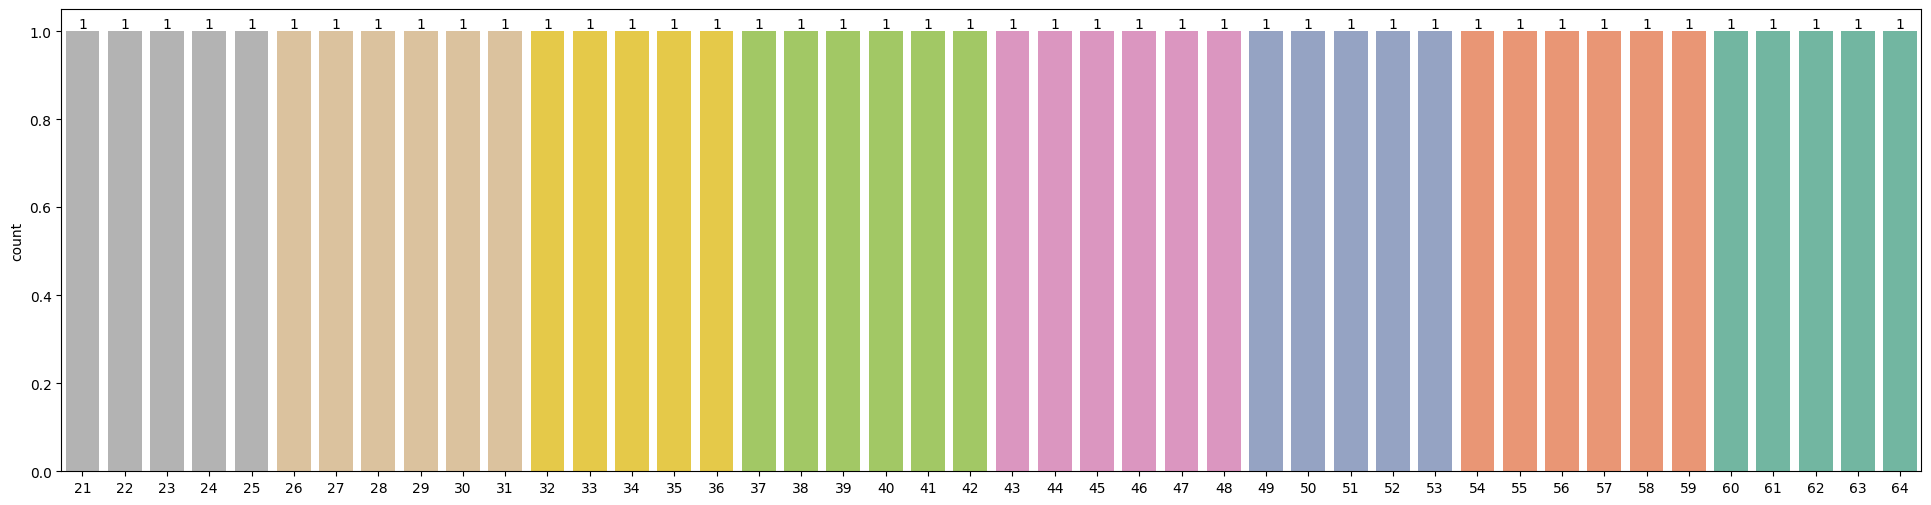

In [10]:
df.age = df.age.astype(int)
plt.figure(figsize=(24,6))
ax = sns.countplot(df["age"], order = range(21,65), palette="Set2_r")
annotate_chart(ax)
plt.show()

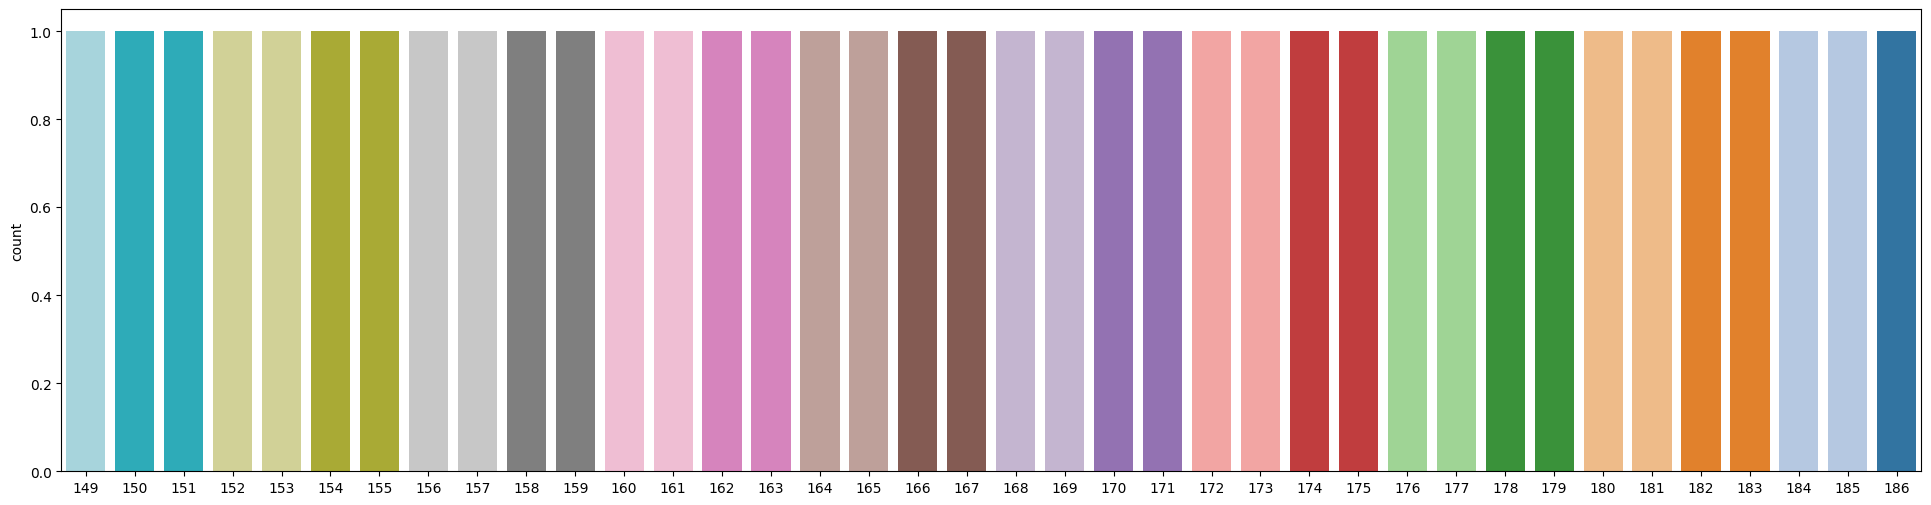

In [11]:
df.height_cm = df.height_cm.astype(int)
plt.figure(figsize=(24,6))
ax = sns.countplot(df["height_cm"], order = range(149,187), palette="tab20_r")
#annotate_chart(ax)
plt.show()

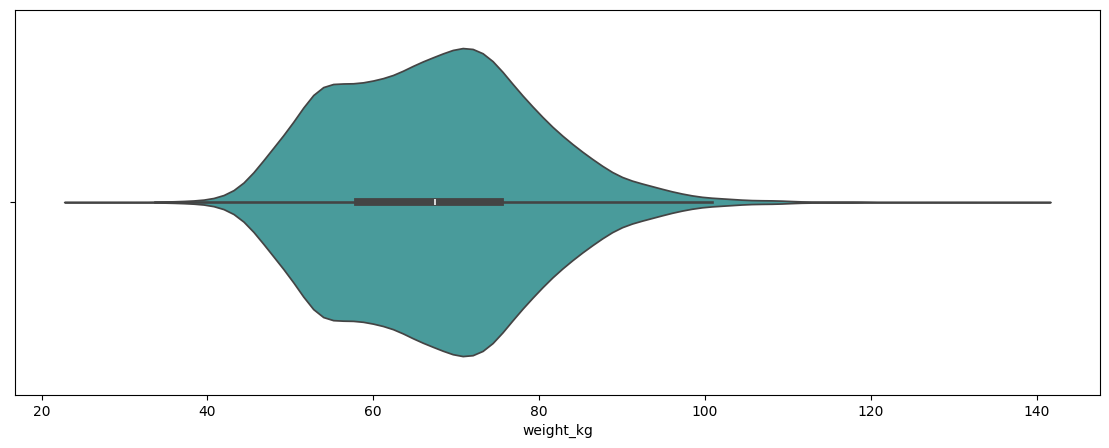

In [12]:
plt.figure(figsize=(14,5))
sns.violinplot(data=df, x="weight_kg",color='#3BA9A9')
plt.show()

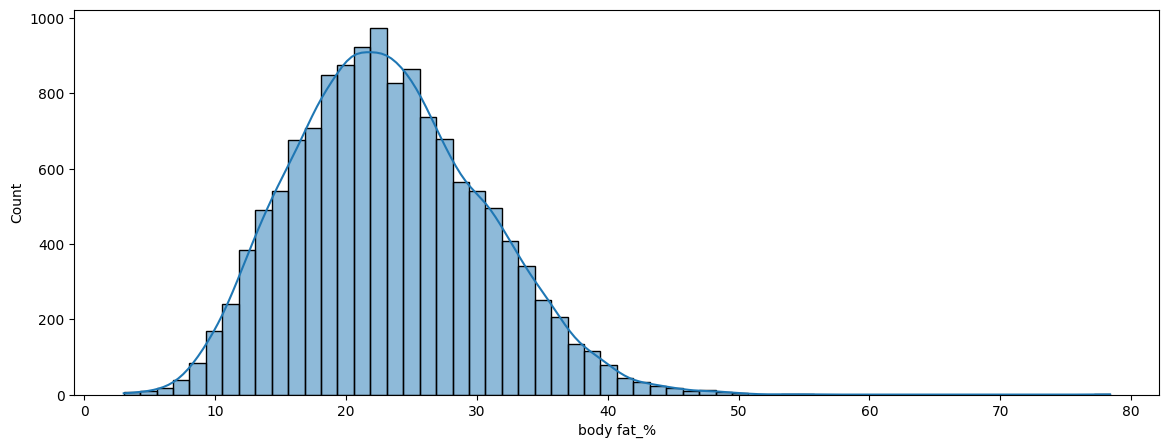

In [13]:
plt.figure(figsize=(14,5))
sns.histplot(data=df, x="body fat_%", bins=60, kde=True)
plt.show()

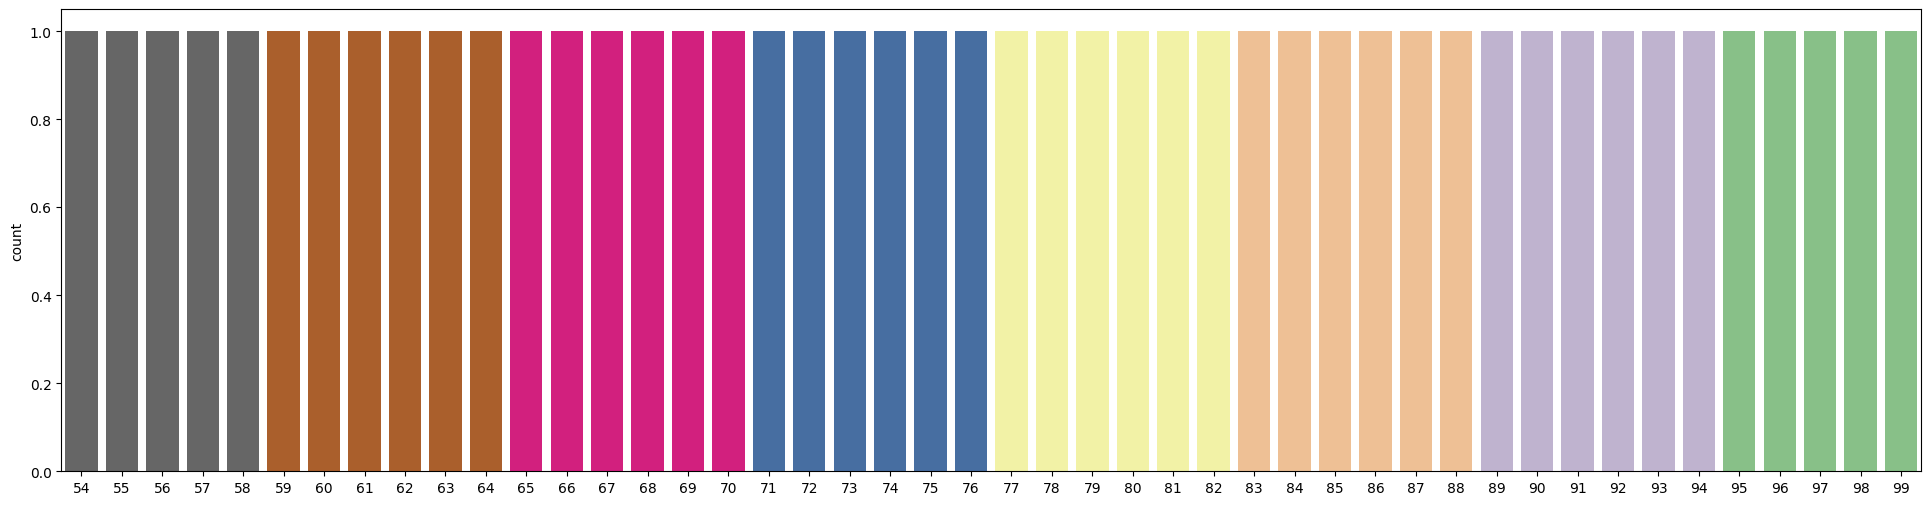

In [14]:
df.diastolic = df.diastolic.astype(int)
plt.figure(figsize=(24,6))
ax = sns.countplot(df["diastolic"], order = range(54,100), palette="Accent_r")
#annotate_chart(ax)
plt.show()

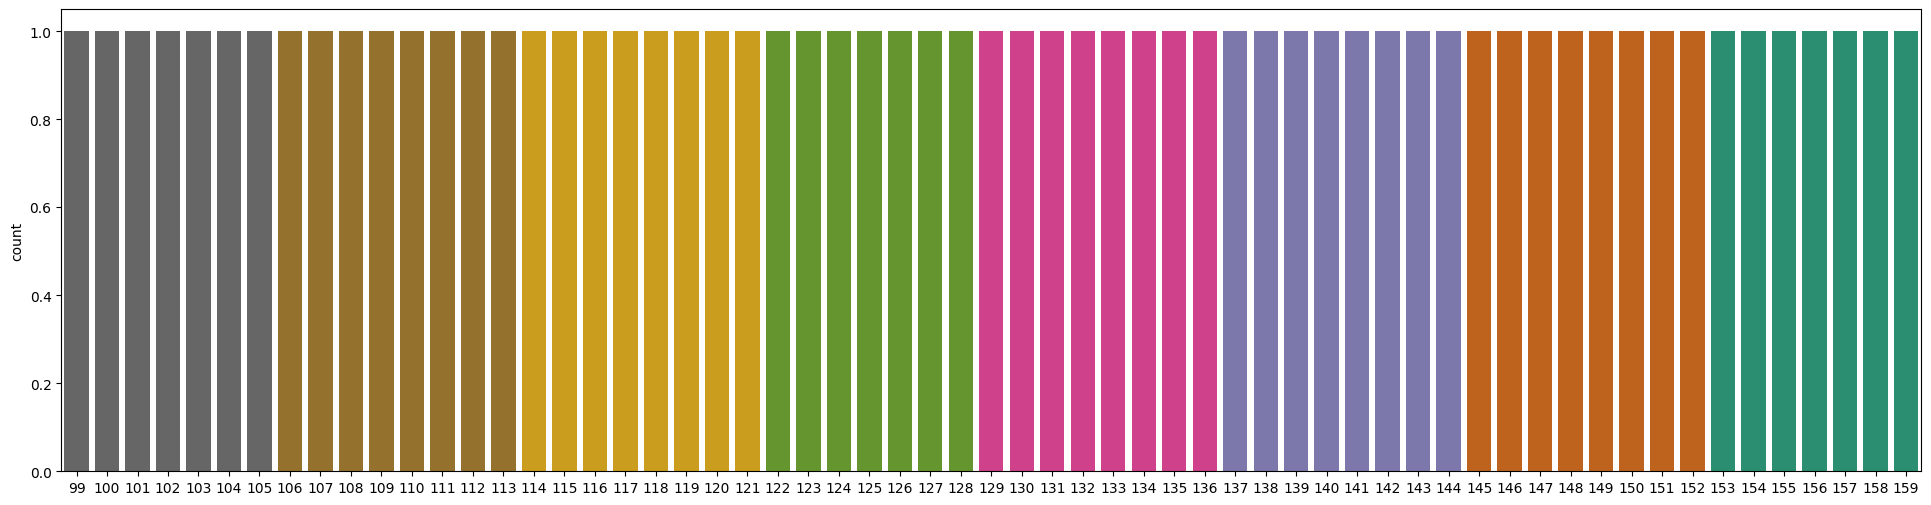

In [15]:
df.systolic = df.systolic.astype(int)
plt.figure(figsize=(24,6))
ax = sns.countplot(df["systolic"], order = range(99,160), palette="Dark2_r")
#annotate_chart(ax)
plt.show()

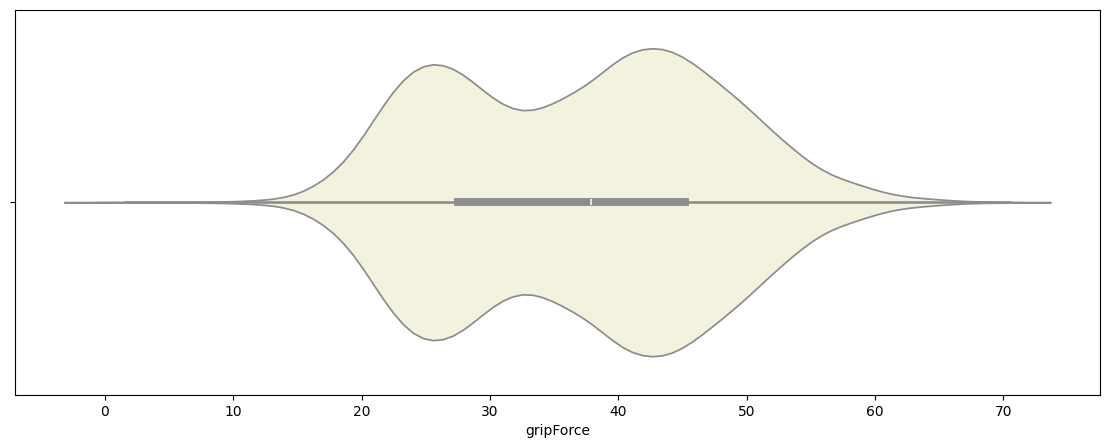

In [16]:
plt.figure(figsize=(14,5))
sns.violinplot(data=df, x="gripForce",color='beige')
plt.show()

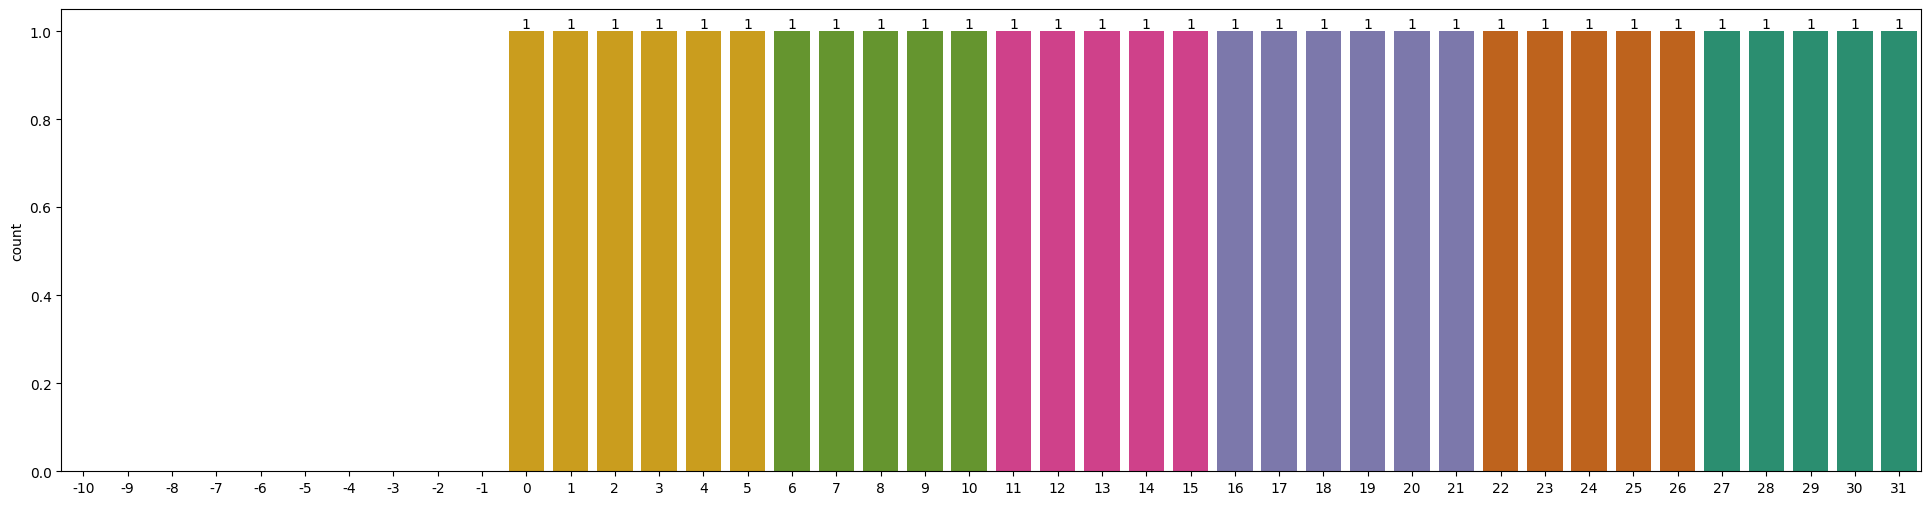

In [17]:
df["sit and bend forward_cm"] = df["sit and bend forward_cm"].astype(int)
plt.figure(figsize=(24,6))
ax = sns.countplot(df["sit and bend forward_cm"],order=range(-10,32), palette="Dark2_r")
annotate_chart(ax)
plt.show()

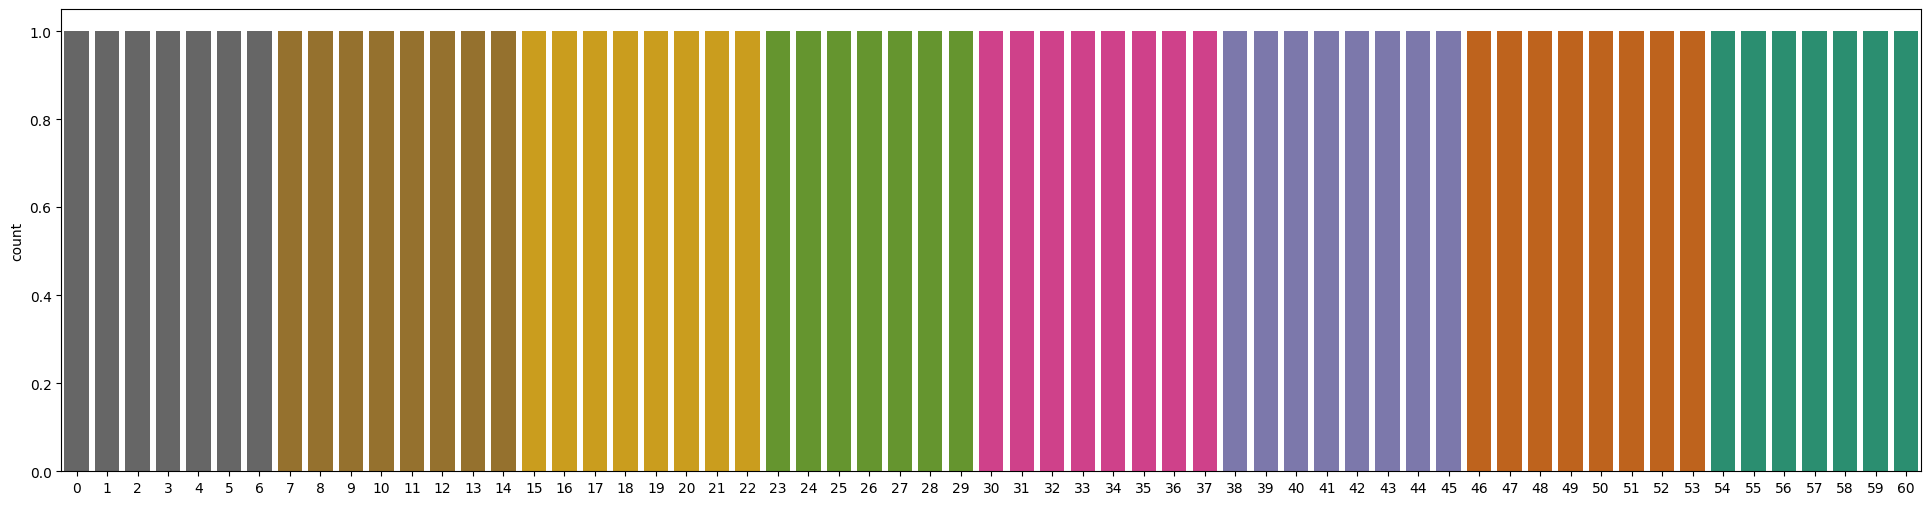

In [18]:
df["sit-ups counts"] = df["sit-ups counts"].astype(int)
plt.figure(figsize=(24,6))
ax = sns.countplot(df["sit-ups counts"],order=range(0,61), palette="Dark2_r")
plt.show()

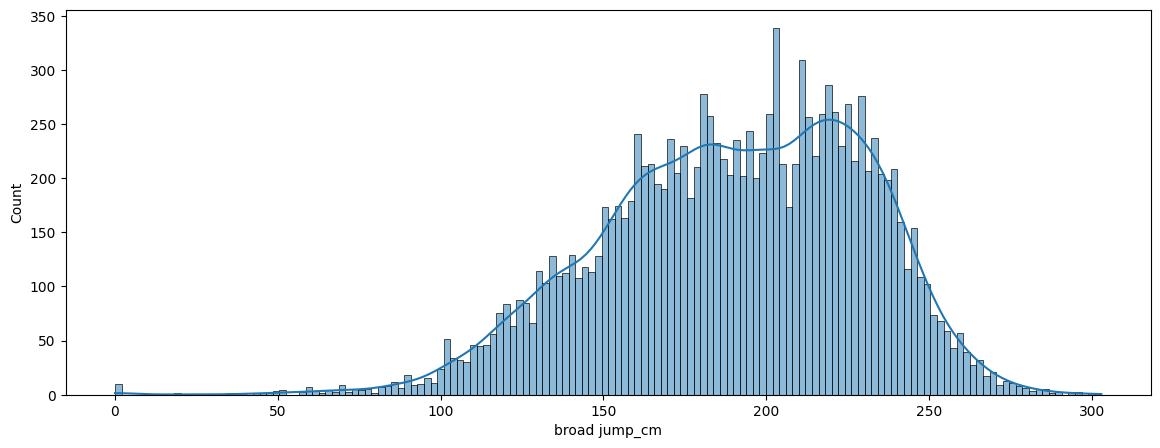

In [19]:
plt.figure(figsize=(14,5))
sns.histplot(data=df, x="broad jump_cm", bins=150, kde=True)
plt.show()

# outliers

<Axes: >

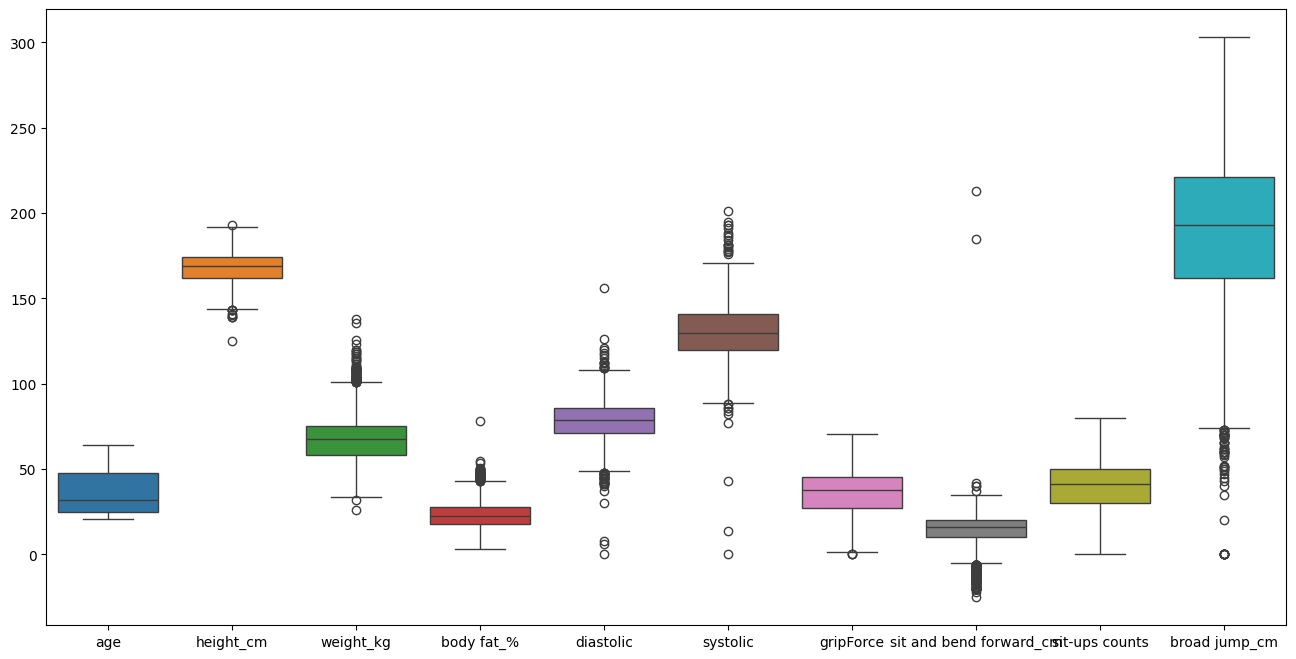

In [20]:
plt.figure(figsize=(16,8))
sns.boxplot(data=df)

# preprocesssing

In [21]:
df.rename(columns={"height_cm": "height", "weight_kg": "weight","body fat_%":"body_fat",
                   "sit and bend forward_cm":"sit_and_bend_forward","sit-ups counts":"sit-ups",
                   "broad jump_cm":"broad_jump","class":"performance"},inplace=True)

In [22]:
df.age = df.age.astype(int)

gender = {'F':0,'M':1}
df['gender'] =df['gender'].replace(gender)

def BMI (row):
    bmi = ((row.weight/row.height)/row.height)*10000
    if bmi>=18.5 and bmi < 25:
        return 0
    elif bmi < 18.5:
        return 1
    elif bmi >= 25 and bmi < 30:
        return 2
    else:
        return 4

df['BMI'] = df.apply(BMI,axis=1)

df = df[(df["body_fat"] <= 42)]

df["sit_and_bend_forward"] = df["sit_and_bend_forward"]+25

df = df[(df["sit_and_bend_forward"] <= 57)]

Class = {'A':0, 'B':1, 'C':2, 'D':3}
df['class'] =df['performance'].replace(Class)

df.drop(['height','weight','diastolic','systolic','performance'],axis=1, inplace=True)

In [23]:
df

,age,gender,body_fat,gripForce,sit_and_bend_forward,sit-ups,broad_jump,BMI,class
0,27,1,21.3,54.9,43,60,217.0,2,2
1,25,1,15.7,36.4,41,53,229.0,0,0
2,31,1,20.1,44.8,37,49,181.0,0,2
3,32,1,18.4,41.4,40,53,219.0,0,1
4,28,1,17.1,43.5,52,45,217.0,0,1
...,...,...,...,...,...,...,...,...,...
13388,25,1,16.2,35.8,42,47,198.0,0,2
13389,21,1,12.1,33.0,26,48,167.0,0,3
13390,39,1,20.1,63.5,41,45,229.0,2,0
13391,64,0,40.4,19.3,34,0,75.0,2,3


In [24]:
df.describe()

,age,gender,body_fat,gripForce,sit_and_bend_forward,sit-ups,broad_jump,BMI,class
count,13252.000000,13252.000000,13252.000000,13252.000000,13252.000000,13252.000000,13252.000000,13252.000000,13252.000000
mean,36.727664,0.637187,23.063675,37.079008,39.789239,39.985210,190.711221,0.659297,1.490643
std,13.603493,0.480830,7.001797,10.592636,7.989344,14.099106,39.373960,1.022379,1.114725
min,21.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,18.000000,27.700000,35.000000,31.000000,163.000000,0.000000,0.000000
50%,32.000000,1.000000,22.700000,38.000000,41.000000,42.000000,194.000000,0.000000,1.000000
75%,48.000000,1.000000,27.825000,45.200000,45.000000,51.000000,222.000000,2.000000,2.000000
max,64.000000,1.000000,42.000000,70.500000,57.000000,80.000000,303.000000,4.000000,3.000000


In [25]:
df_copy = df_copy[(df_copy["sit and bend forward_cm"] <= 57)]

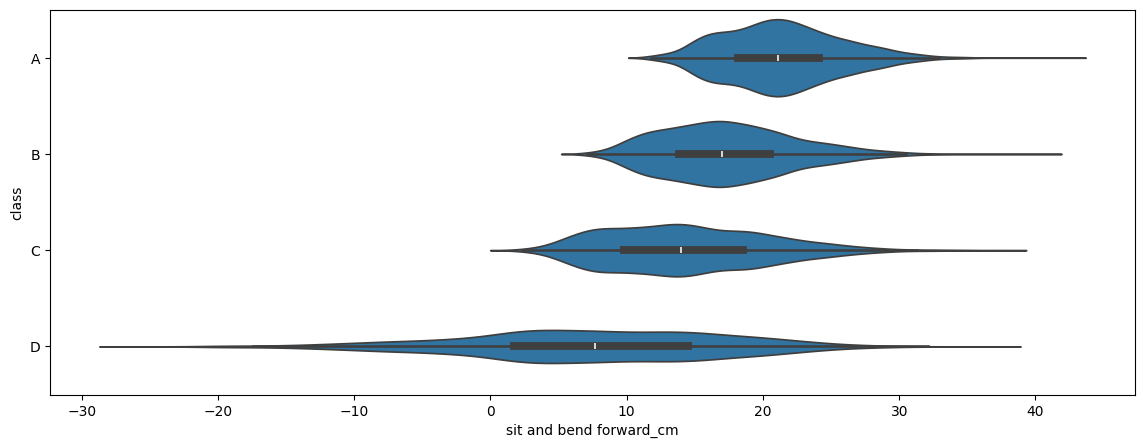

In [26]:
plt.figure(figsize=(14,5))
sns.violinplot(data=df_copy, x="sit and bend forward_cm",y='class',order=['A','B','C','D'])
plt.show()

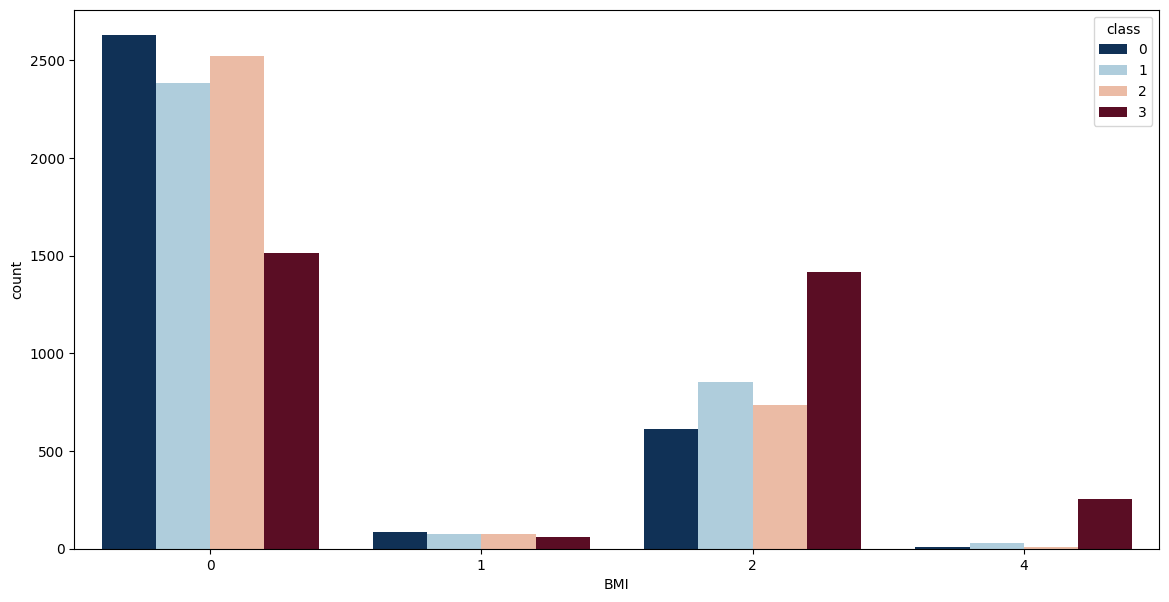

In [27]:
plt.figure(figsize=(14,7))
ax1 = sns.countplot(x = df["BMI"], hue=df["class"],
                    order = [0,1,2,4], hue_order=[0,1,2,3],
                   palette='RdBu_r')

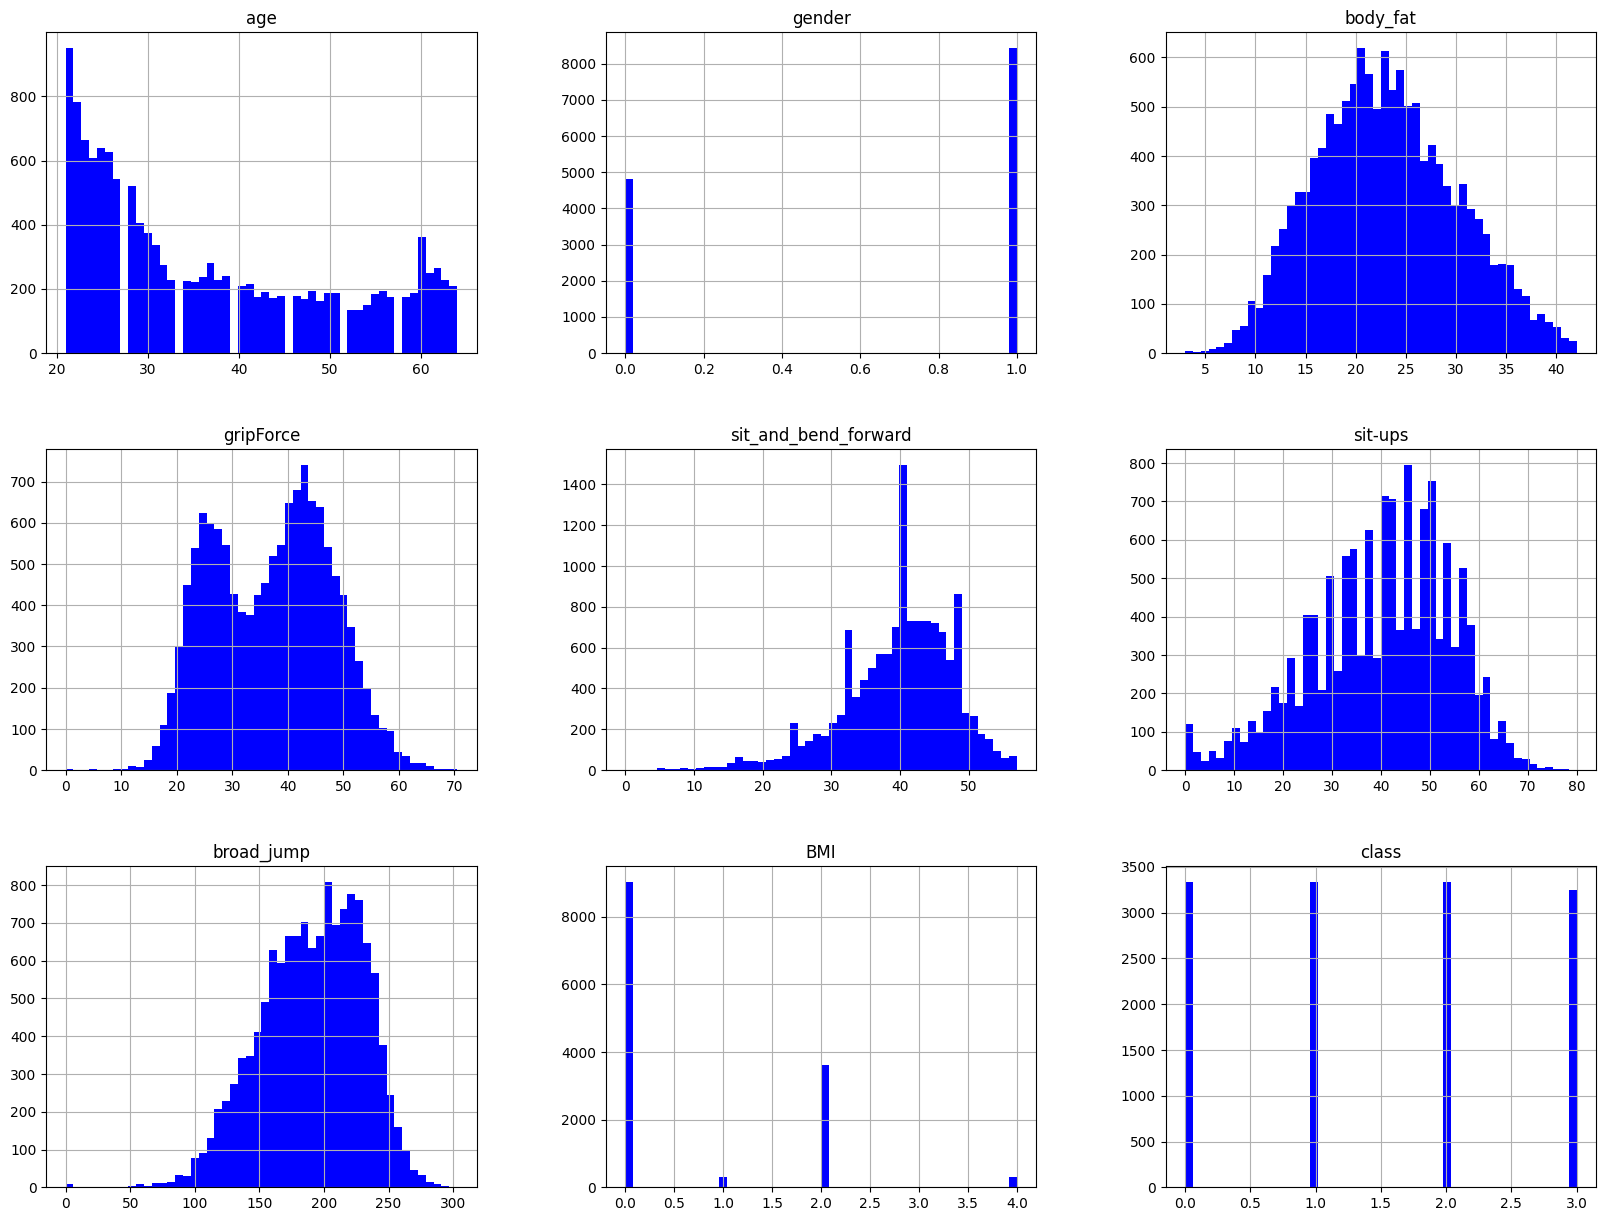

In [28]:
df.hist(bins=50, figsize=(20,15), color='b')
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13252 entries, 0 to 13392
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   13252 non-null  int64  
 1   gender                13252 non-null  int64  
 2   body_fat              13252 non-null  float64
 3   gripForce             13252 non-null  float64
 4   sit_and_bend_forward  13252 non-null  int64  
 5   sit-ups               13252 non-null  int64  
 6   broad_jump            13252 non-null  float64
 7   BMI                   13252 non-null  int64  
 8   class                 13252 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 1.0 MB


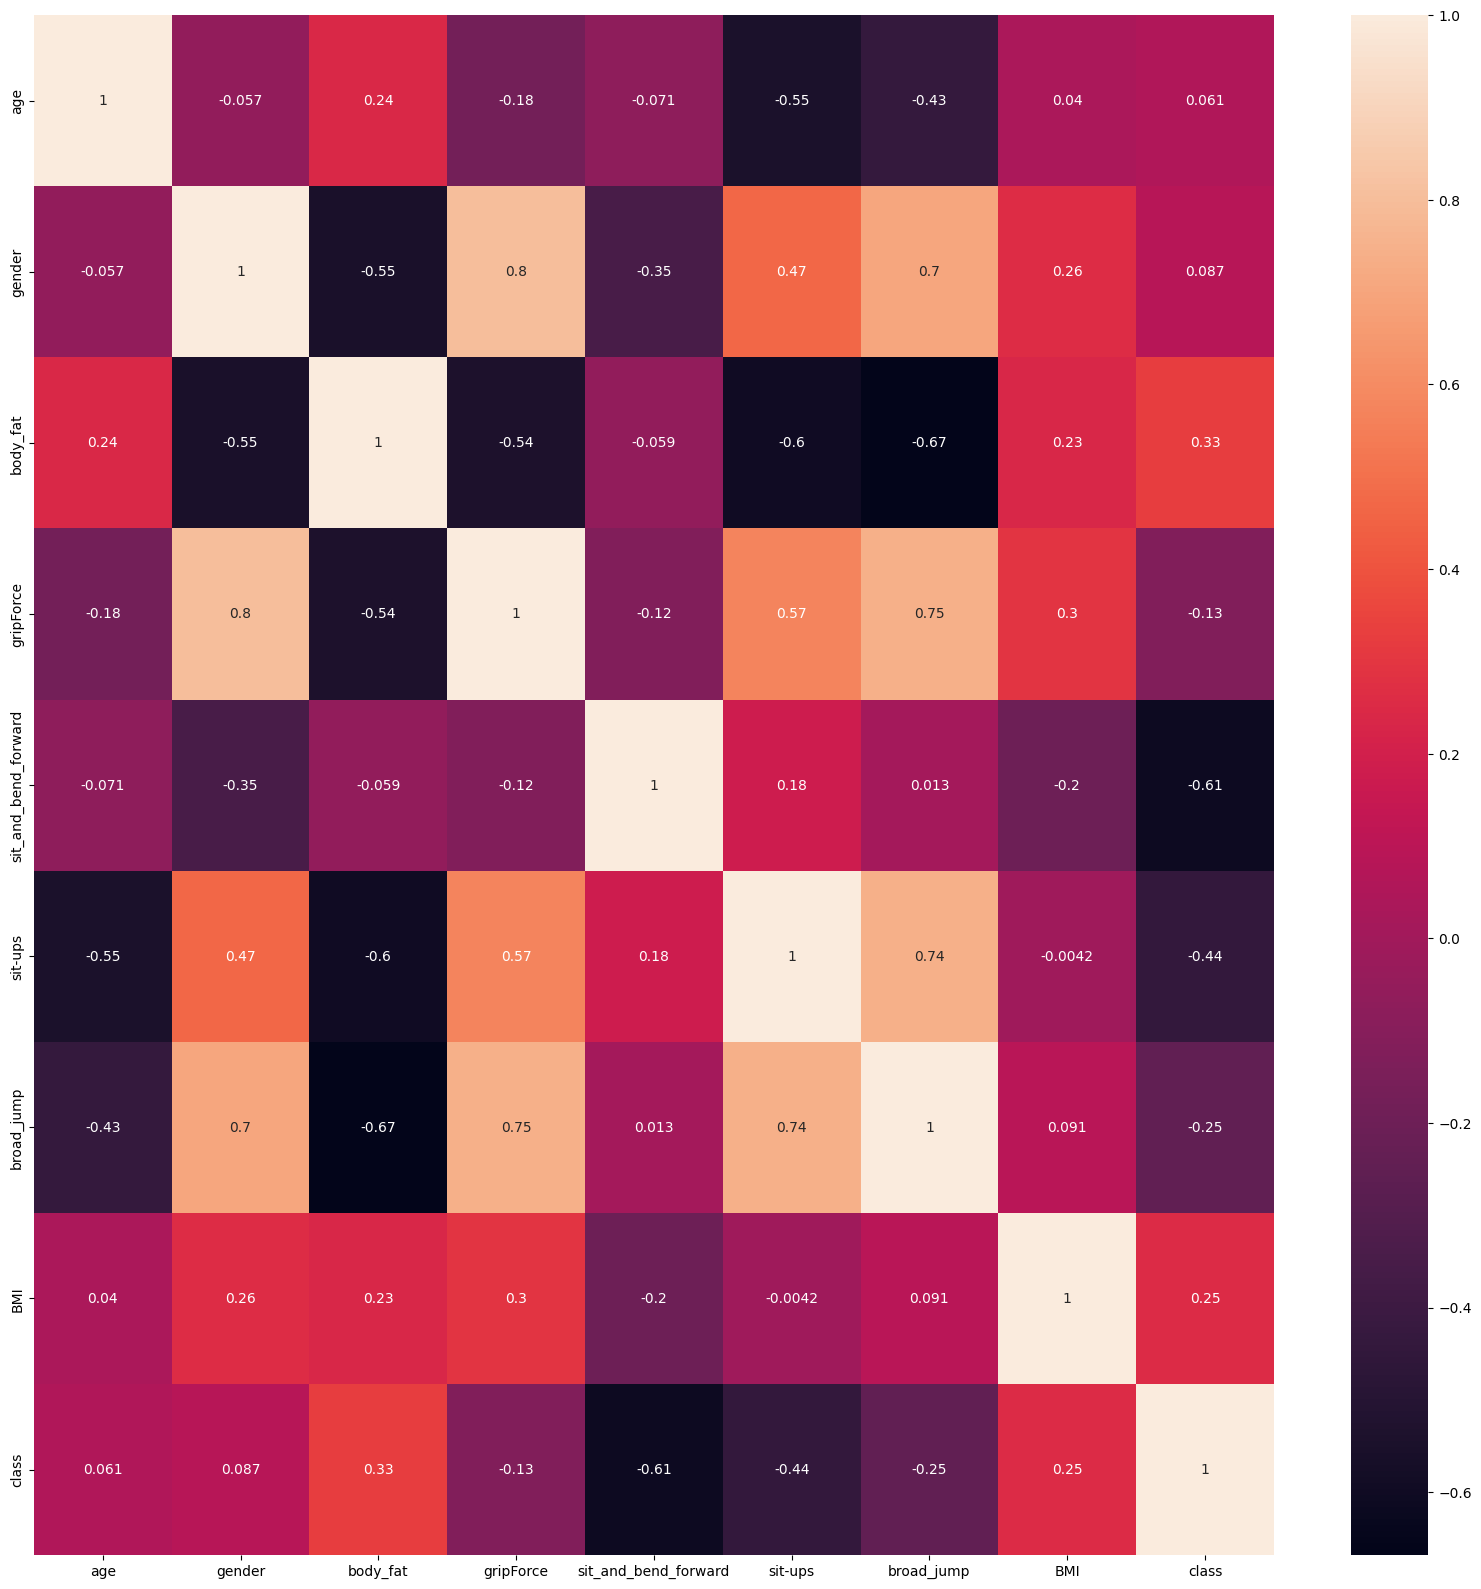

In [30]:
corr_matrix = df.corr()
plt.figure(figsize = (20,20))
sns_plot=sns.heatmap(corr_matrix,annot=True)
plt.show()

# Feature selection

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    "KNN": KNeighborsClassifier(
        n_neighbors=11,        # زودنا عدد الجيران
        weights='distance',
        algorithm='kd_tree',
        leaf_size=30,
        p=2,
        metric='euclidean',    # صححنا الخطأ هنا
        n_jobs=-1              # استخدم كل الكورز
    ),

    "DecisionTree": DecisionTreeClassifier(
        criterion="entropy",        # جربنا entropy
        splitter="best",
        max_depth=20,               # قيد العمق عشان يقل overfitting
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',        # حاول يقلل overfitting
        random_state=42,
        min_impurity_decrease=0.0,
        class_weight='balanced',    # مفيد لو التوزيع غير متساوي
        ccp_alpha=0.0
    ),

    "SVM": SVC(
        C=10.0,               # زيادة regularization
        kernel='rbf',         # rbf عادة الأفضل multiclass
        gamma=0.01,           # أصغر من scale لتحسين التعلم
        tol=1e-3,
        cache_size=500,
        class_weight='balanced',
        probability=True,      # لو عايز predict_proba
        max_iter=10000,
        random_state=42,
        decision_function_shape='ovr'
    ),

    "NeuralNet": MLPClassifier(
        hidden_layer_sizes=(128,64,32),  # layers أكبر
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size='auto',
        learning_rate='adaptive',        # يتعلم بسرعة
        learning_rate_init=0.002,       # زودنا شوية
        max_iter=1500,                   # epochs أعلى
        shuffle=True,
        random_state=42,
        tol=1e-4,
        verbose=False,
        early_stopping=True,            # توقف تلقائي لو validation مش بتحسن
        validation_fraction=0.1,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8
    )
}

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split

# قراءة الداتا
df = pd.read_csv("bodyPerformance.csv")

# تحويل gender لأرقام
df["gender"] = df["gender"].map({"M":1, "F":0})

# تحديد الـ features و target
X = df.drop("class", axis=1)
y = df["class"]

# تقسيم الداتا
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Data split successfully")

Data split successfully


## Hyperparameter Tuning for KNN

### Subtask:
Perform hyperparameter tuning for the KNeighborsClassifier model using GridSearchCV to find the optimal configuration.


**Reasoning**:
I will perform hyperparameter tuning for the KNeighborsClassifier using GridSearchCV to find the optimal configuration based on the provided instructions.



In [36]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

# 1️⃣ Load Data
df = pd.read_csv("bodyPerformance.csv")

# 2️⃣ Convert gender to numeric
df["gender"] = df["gender"].map({"M":1,"F":0})

# 3️⃣ Features and Target
X = df.drop("class",axis=1)
y = df["class"]

# 4️⃣ Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 5️⃣ Pipeline
knn_pipe = Pipeline([

    ("imputer",SimpleImputer(strategy="median")),

    ("scaler",StandardScaler()),

    ("model",KNeighborsClassifier())
])

# 6️⃣ Hyperparameters
param_dist = {

    "model__n_neighbors": range(3,31),

    "model__weights": ["uniform","distance"],

    "model__metric": ["euclidean","manhattan","minkowski"],

    "model__p":[1,2]
}

# 7️⃣ Randomized Search
search = RandomizedSearchCV(

    knn_pipe,

    param_distributions=param_dist,

    n_iter=40,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    random_state=42,

    verbose=2
)

print("Training Model...")

search.fit(X_train,y_train)

# 8️⃣ Best Parameters
print("\nBest Parameters:")
print(search.best_params_)

print("\nBest CV Accuracy:")
print(search.best_score_)

# 9️⃣ Test Accuracy
best_model = search.best_estimator_

pred = best_model.predict(X_test)

print("\nTest Accuracy:")
print(accuracy_score(y_test,pred))

print("\nClassification Report:")
print(classification_report(y_test,pred))

Training Model...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 24, 'model__metric': 'manhattan'}

Best CV Accuracy:
0.6366422194947352

Test Accuracy:
0.6502426278462112

Classification Report:
              precision    recall  f1-score   support

           A       0.64      0.85      0.73       670
           B       0.50      0.50      0.50       669
           C       0.61      0.57      0.59       670
           D       0.94      0.68      0.79       670

    accuracy                           0.65      2679
   macro avg       0.67      0.65      0.65      2679
weighted avg       0.67      0.65      0.65      2679



## Hyperparameter Tuning for Decision Tree

### Subtask:
Perform hyperparameter tuning for the DecisionTreeClassifier model using GridSearchCV to find the optimal configuration.


**Reasoning**:
I will perform hyperparameter tuning for the DecisionTreeClassifier using GridSearchCV, defining a parameter grid for criterion, max_depth, min_samples_split, and min_samples_leaf, then fitting it to the training data within a pipeline.



In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1️⃣ Load Data
df = pd.read_csv("bodyPerformance.csv")

# 2️⃣ Convert gender to numeric
df["gender"] = df["gender"].map({"M":1, "F":0})

# 3️⃣ Features & Target
X = df.drop("class", axis=1)
y = df["class"]

# 4️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 5️⃣ Pipeline
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # handle NaN
    ("scaler", StandardScaler()),  # optional, DT مش حساس للـ scale
    ("model", DecisionTreeClassifier(random_state=42))
])

# 6️⃣ Hyperparameter Grid
param_grid_dt = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 10, 15, 20, 25, 30],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": [None, "sqrt", "log2"]
}

# 7️⃣ Cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 8️⃣ GridSearchCV
dt_grid_search = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid_dt,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

print("Training Decision Tree...")
dt_grid_search.fit(X_train, y_train)

# 9️⃣ Best Parameters & CV Accuracy
print("\nBest Parameters:", dt_grid_search.best_params_)
print("Best CV Accuracy:", dt_grid_search.best_score_)

# 10️⃣ Test Accuracy
best_dt = dt_grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training Decision Tree...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 15}
Best CV Accuracy: 0.674538124473619

Test Accuracy: 0.6808510638297872

Classification Report:
               precision    recall  f1-score   support

           A       0.65      0.90      0.75       670
           B       0.55      0.51      0.53       669
           C       0.70      0.54      0.61       670
           D       0.86      0.77      0.81       670

    accuracy                           0.68      2679
   macro avg       0.69      0.68      0.68      2679
weighted avg       0.69      0.68      0.68      2679



## Hyperparameter Tuning for SVM

### Subtask:
Perform hyperparameter tuning for the SVC model using GridSearchCV to find the optimal configuration.


**Reasoning**:
I will perform hyperparameter tuning for the SVC model using GridSearchCV by defining a parameter grid for C, kernel, and gamma, and executing the search within a pipeline that includes feature scaling.



In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define the parameter grid for SVM
param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

# 2. Create the Pipeline with StandardScaler and SVC
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

# 3. Initialize GridSearchCV
svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Fit GridSearchCV to the training data
print('Starting Grid Search for SVM...')
svm_grid_search.fit(X_train, y_train)

# 5. Print the results
print('\nBest Parameters found:', svm_grid_search.best_params_)
print('Best Cross-Validation Accuracy:', svm_grid_search.best_score_)

Starting Grid Search for SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters found: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.7024461550057883


In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

# 1️⃣ Pipeline: Imputer + Scaler + SVM
svm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # تعويض missing values
    ("scaler", StandardScaler()),                  # scale مهم للـ SVM
    ("model", SVC(probability=True, random_state=42, max_iter=5000))  # SVC مع max_iter محدود لتسريع
])

# 2️⃣ Hyperparameters محسّنة (نطاق أصغر لتسريع)
param_dist_svm = {
    "model__C": [1, 5, 10, 20],         # أقل من 50 و100 لتسريع
    "model__kernel": ["rbf"],           # rbf أسرع وأكثر استقرارًا من poly
    "model__gamma": ["scale", 0.01, 0.001]  # نطاق معقول
}

# 3️⃣ Cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4️⃣ RandomizedSearchCV أسرع من GridSearch
svm_search = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=param_dist_svm,
    n_iter=15,          # جرب 15 تركيبة فقط لتسريع
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# 5️⃣ تدريب SVM
print("Training SVM...")
svm_search.fit(X_train, y_train)

# 6️⃣ أفضل باراميترز وCV Accuracy
print("\nBest Parameters:", svm_search.best_params_)
print("Best CV Accuracy:", svm_search.best_score_)

# 7️⃣ تقييم على Test Set
best_svm = svm_search.best_estimator_
y_pred = best_svm.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


## Hyperparameter Tuning for NeuralNet

### Subtask:
Perform hyperparameter tuning for the MLPClassifier (NeuralNet) model using GridSearchCV to find the optimal configuration.


**Reasoning**:
I will perform hyperparameter tuning for the MLPClassifier using GridSearchCV, defining a parameter grid for hidden layers, activation, solver, alpha, and learning rate, then fitting it to the training data within a scaled pipeline.



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for MLPClassifier
param_grid_nn = {
    'model__hidden_layer_sizes': [(50,), (10, 40)],
    'model__activation': ['tanh', 'relu'],
    'model__solver': ['adam', 'sgd'],
    'model__alpha': [0.0001, 0.05],
    'model__learning_rate_init': [0.001, 0.01]
}

# 2. Create the Pipeline with StandardScaler and MLPClassifier
nn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(max_iter=500, random_state=42))
])

# 3. Initialize GridSearchCV
nn_grid_search = GridSearchCV(
    estimator=nn_pipe,
    param_grid=param_grid_nn,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Fit GridSearchCV to the training data
print('Starting Grid Search for Neural Network...')
nn_grid_search.fit(X_train, y_train)

# 5. Print the results
print('\nBest Parameters found:', nn_grid_search.best_params_)
print('Best Cross-Validation Accuracy:', nn_grid_search.best_score_)

In [ ]:
from sklearn.metrics import accuracy_score

for name,model in trained_models.items():

    pred = model.predict(X_test)

    print(name)
    print("Test Accuracy:",accuracy_score(y_test,pred))
    print("--------------")

In [ ]:
trained_models = {
    "KNN": grid_search.best_estimator_,
    "DecisionTree": dt_grid_search.best_estimator_,
    "SVM": svm_grid_search.best_estimator_,
    "NeuralNet": nn_grid_search.best_estimator_,
}

best_results = {
    'KNN': {'params': grid_search.best_params_, 'score': grid_search.best_score_},
    'DecisionTree': {'params': dt_grid_search.best_params_, 'score': dt_grid_search.best_score_},
    'SVM': {'params': svm_grid_search.best_params_, 'score': svm_grid_search.best_score_},
    'NeuralNet': {'params': nn_grid_search.best_params_, 'score': nn_grid_search.best_score_}
}

print("--- Final Hyperparameter Tuning Comparison ---")
overall_best_model = None
overall_best_accuracy = 0

for model_name, results in best_results.items():
    print(f"\nModel: {model_name}")
    print(f"Best Parameters: {results['params']}")
    print(f"Best CV Accuracy: {results['score']:.4f}")

    if results['score'] > overall_best_accuracy:
        overall_best_accuracy = results['score']
        overall_best_model = model_name

print(f"\n{'='*40}")
print(f"Overall Best Model: {overall_best_model}")
print(f"Highest Accuracy: {overall_best_accuracy:.4f}")
print(f"{'='*40}")

In [ ]:
# Consolidating results from all GridSearchCV objects
model_summary = {
    'KNN': {'best_params': grid_search.best_params_, 'best_score': grid_search.best_score_},
    'Decision Tree': {'best_params': dt_grid_search.best_params_, 'best_score': dt_grid_search.best_score_},
    'SVM': {'best_params': svm_grid_search.best_params_, 'best_score': svm_grid_search.best_score_},
    'Neural Network': {'best_params': nn_grid_search.best_params_, 'best_score': nn_grid_search.best_score_}
}

print("--- Hyperparameter Tuning Summary Results ---")
overall_best_model = None
overall_best_accuracy = 0

for model_name, results in model_summary.items():
    print(f"\nModel: {model_name}")
    print(f"Best Parameters: {results['best_params']}")
    print(f"Best Cross-Validation Accuracy: {results['best_score']:.4f}")

    if results['best_score'] > overall_best_accuracy:
        overall_best_accuracy = results['best_score']
        overall_best_model = model_name

print(f"\n{'='*50}")
print(f"Overall Best Performing Model: {overall_best_model}")
print(f"Highest Accuracy Achieved: {overall_best_accuracy:.4f}")
print(f"{'='*50}")

In [ ]:

import matplotlib.pyplot as plt
%matplotlib inline

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    train_sizes, train_scores, test_scores = learning_curve(
        pipe,
        X,
        y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(6,4))

    plt.plot(train_sizes, train_mean, label="Training score")
    plt.plot(train_sizes, test_mean, label="Validation score")

    plt.title(name + " Learning Curve")

    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")

    plt.legend()
    plt.grid()

    plt.show()